GENERATING NON LINEAR TRAINING DATA

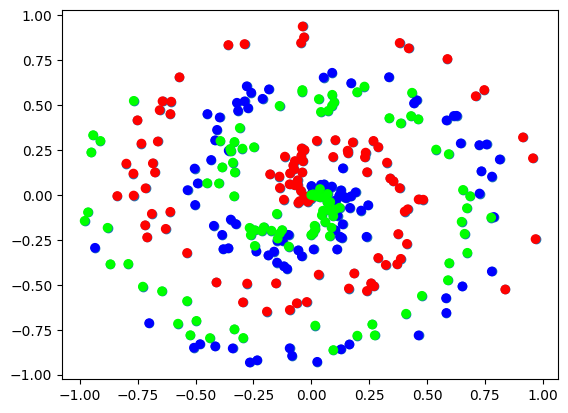

In [5]:
from nnfs.datasets import spiral_data
import numpy as np
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X, y = spiral_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

DENSE LAYER CLASS

In [6]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()
# Dense layer
class Layer_Dense:
 # Layer initialization
 def __init__(self, n_inputs, n_neurons):
 # Initialize weights and biases
   self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
   self.biases = np.zeros((1, n_neurons))

 # Forward pass
 def forward(self, inputs):
 # Calculate output values from inputs, weights and biases
   self.output = np.dot(inputs, self.weights) + self.biases

# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Perform a forward pass of our training data through this layer
dense1.forward(X)


# Let's see output of the first few samples:
print(dense1.output[:5])


[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [-1.0475188e-04  1.1395361e-04 -4.7983500e-05]
 [-2.7414842e-04  3.1729150e-04 -8.6921798e-05]
 [-4.2188365e-04  5.2666257e-04 -5.5912682e-05]
 [-5.7707680e-04  7.1401405e-04 -8.9430439e-05]]


ACTIVATION FUNCTION: RELU

In [7]:
# ReLU activation
class Activation_ReLU:
 # Forward pass
 def forward(self, inputs):
 # Calculate output values from input
  self.output = np.maximum(0, inputs)

In [8]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()
# Make a forward pass of our training data through this layer
dense1.forward(X)
# Forward pass through activation func.
# Takes in output from previous layer
activation1.forward(dense1.output)
# Let's see output of the first few samples:
print(activation1.output[:5])

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


ACTIVATION FUNCTION: SOFTMAX

In [9]:
# Softmax activation
class Activation_Softmax:
 # Forward pass
 def forward(self, inputs):
 # Get unnormalized probabilities
  exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
 # Normalize them for each sample
  probabilities = exp_values / np.sum(exp_values, axis=1,keepdims=True)
  self.output = probabilities

ONE FORWARD PASS (WITHOUT LOSS)

In [10]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()
# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values
dense2 = Layer_Dense(3, 3)
# Create Softmax activation (to be used with Dense layer):
activation2 = Activation_Softmax()

# Make a forward pass of our training data through this layer
dense1.forward(X)

# Make a forward pass through activation function
# it takes the output of first dense layer here
activation1.forward(dense1.output)
# Make a forward pass through second Dense layer
# it takes outputs of activation function of first layer as inputs
dense2.forward(activation1.output)
# Make a forward pass through activation function
# it takes the output of second dense layer here
activation2.forward(dense2.output)
# Let's see output of the first few samples:
print(activation2.output[:5])

[[0.33333334 0.33333334 0.33333334]
 [0.33333364 0.3333334  0.3333329 ]
 [0.33333385 0.33333346 0.33333266]
 [0.33333433 0.3333336  0.3333321 ]
 [0.33333465 0.33333373 0.33333164]]


CALCULATING NETWORK ERROR WITH LOSS


CROSS ENTROPY LOSS BUILDING BLOCKS IN PYTHON

In [11]:
softmax_outputs = np.array([[0.7, 0.1, 0.2],
 [0.1, 0.5, 0.4],
 [0.02, 0.9, 0.08]])
class_targets = [0, 1, 1]
print(softmax_outputs[range(len(softmax_outputs)), class_targets])

[0.7 0.5 0.9]


In [12]:
range(len(softmax_outputs))

range(0, 3)

In [13]:
print(-np.log(softmax_outputs[
 range(len(softmax_outputs)), class_targets
]))
neg_log = -np.log(softmax_outputs[
 range(len(softmax_outputs)), class_targets
 ])
average_loss = np.mean(neg_log)
print(average_loss)

[0.35667494 0.69314718 0.10536052]
0.38506088005216804


IF DATA IS ONE HOT ENCODED, HOW TO EXTRACT THE RELEVANT PREDICTIONS

In [14]:
y_true_check = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 1, 0]
])

y_pred_clipped_check = np.array([
    [0.7, 0.2, 0.1],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])

A = y_true_check*y_pred_clipped_check
B = np.sum(A, axis = 1)
C = - np.log(B)

print(C)
print(np.mean(C))



[0.35667494 0.69314718 0.10536052]
0.38506088005216804


IMPLEMENTING THE LOSS CLASS

In [15]:
# Common loss class
class Loss:
 # Calculates the data and regularization losses
 # given model output and ground truth values
 def calculate(self, output, y):
  # Calculate sample losses
  sample_losses = self.forward(output, y)
  # Calculate mean loss
  data_loss = np.mean(sample_losses)
  # Return loss
  return data_loss

IMPLEMENTING THE CATEGORICAL CROSS ENTROPY CLASS

In [34]:
class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        # Number of samples in a batch
        samples = len(y_pred)
        
        # Clip data to prevent division by 0 (log(0) is undefined)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        # Probabilities for target values - if discrete labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true]
        # Mask values - if one-hot encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)

        # Losses calculation
        negative_log_likelihoods = -np.log(correct_confidences)
        
        # CRITICAL: You must return the losses for np.mean() to work
        return negative_log_likelihoods

FULL CODE UP TO THIS POINT

In [35]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()
# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values
dense2 = Layer_Dense(3, 3)
# Create Softmax activation (to be used with Dense layer):
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()


# Perform a forward pass of our training data through this layer
dense1.forward(X)
# Perform a forward pass through activation function
# it takes the output of first dense layer here
activation1.forward(dense1.output)

# Perform a forward pass through second Dense layer
# it takes outputs of activation function of first layer as inputs
dense2.forward(activation1.output)
# Perform a forward pass through activation function
# it takes the output of second dense layer here
activation2.forward(dense2.output)
# Let's see output of the first few samples:
print(activation2.output[:5])
# Perform a forward pass through activation function
# it takes the output of second dense layer here and returns loss
loss = loss_function.calculate(activation2.output, y)
# Print loss value
print('loss:', loss)

# Calculate accuracy from output of activation2 and targets
# calculate values along first axis
predictions = np.argmax(activation2.output, axis=1)
if len(y.shape) == 2:
 y = np.argmax(y, axis=1)
accuracy = np.mean(predictions == y)
# Print accuracy
print('acc:', accuracy)

[[0.33333334 0.33333334 0.33333334]
 [0.33333325 0.3333336  0.33333316]
 [0.3333331  0.33333397 0.3333329 ]
 [0.33333305 0.3333343  0.3333327 ]
 [0.33333296 0.33333457 0.3333325 ]]
loss: 1.0986109
acc: 0.32


INTRODUCING ACCURACY

In [36]:
import numpy as np
# Probabilities of 3 samples
softmax_outputs = np.array([[0.7, 0.2, 0.1],
 [0.1, 0.5, 0.4],
 [0.02, 0.9, 0.08]])
# Target (ground-truth) labels for 3 samples
class_targets = np.array([0, 1, 1])
# Calculate values along second axis (axis of index 1)
predictions = np.argmax(softmax_outputs, axis=1)
# If targets are one-hot encoded - convert them
if len(class_targets.shape) == 2:
 class_targets = np.argmax(class_targets, axis=1)
# True evaluates to 1; False to 0
accuracy = np.mean(predictions == class_targets)
print('acc:', accuracy)

acc: 1.0


THE NEED FOR OPTIMIZATION

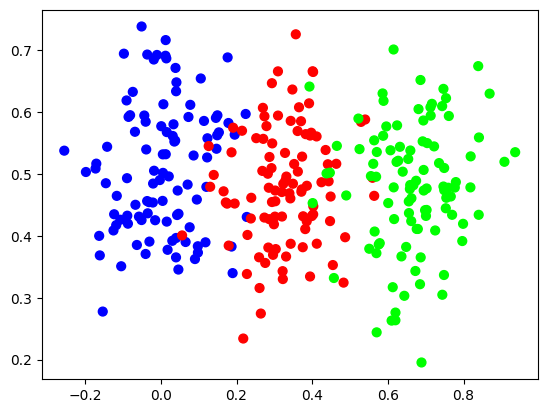

In [37]:
#SIMPLER DATASET
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data
nnfs.init()
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg')
plt.show()

STRATEGY 1: RANDOMLY SELECT WEIGHTS AND BIASES - DOES NOT WORK!

In [38]:
# Create dataset
X, y = vertical_data(samples=100, classes=3)
# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()

# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
 # Generate a new set of weights for iteration
 dense1.weights = 0.05 * np.random.randn(2, 3)
 dense1.biases = 0.05 * np.random.randn(1, 3)
 dense2.weights = 0.05 * np.random.randn(3, 3)
 dense2.biases = 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of the training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
   print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
   best_dense1_weights = dense1.weights.copy()
   best_dense1_biases = dense1.biases.copy()
   best_dense2_weights = dense2.weights.copy()
   best_dense2_biases = dense2.biases.copy()
   lowest_loss = loss

New set of weights found, iteration: 0 loss: 1.1016203 acc: 0.3333333333333333
New set of weights found, iteration: 1 loss: 1.1002508 acc: 0.3333333333333333
New set of weights found, iteration: 2 loss: 1.0992025 acc: 0.3333333333333333
New set of weights found, iteration: 3 loss: 1.0986239 acc: 0.3333333333333333
New set of weights found, iteration: 10 loss: 1.0984299 acc: 0.3333333333333333
New set of weights found, iteration: 22 loss: 1.0976521 acc: 0.36333333333333334
New set of weights found, iteration: 150 loss: 1.0974255 acc: 0.3333333333333333
New set of weights found, iteration: 874 loss: 1.0972673 acc: 0.3333333333333333
New set of weights found, iteration: 894 loss: 1.096895 acc: 0.3333333333333333
New set of weights found, iteration: 1036 loss: 1.0954281 acc: 0.3333333333333333
New set of weights found, iteration: 88633 loss: 1.0952065 acc: 0.3333333333333333


STRATEGY 2: RANDOMLY ADJUST WEIGHTS AND BIASES - WORKS!

In [39]:
# Create dataset
X, y = vertical_data(samples=100, classes=3)
# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()
# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()
for iteration in range(10000):
 # Update weights with some small random values
 dense1.weights += 0.05 * np.random.randn(2, 3)
 dense1.biases += 0.05 * np.random.randn(1, 3)
 dense2.weights += 0.05 * np.random.randn(3, 3)
 dense2.biases += 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of our training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
  best_dense1_weights = dense1.weights.copy()
  best_dense1_biases = dense1.biases.copy()
  best_dense2_weights = dense2.weights.copy()
  best_dense2_biases = dense2.biases.copy()
  lowest_loss = loss
 # Revert weights and biases
 else:
  dense1.weights = best_dense1_weights.copy()
  dense1.biases = best_dense1_biases.copy()
  dense2.weights = best_dense2_weights.copy()
  dense2.biases = best_dense2_biases.copy()

New set of weights found, iteration: 0 loss: 1.1008747 acc: 0.3333333333333333
New set of weights found, iteration: 3 loss: 1.1005715 acc: 0.3333333333333333
New set of weights found, iteration: 4 loss: 1.099462 acc: 0.3333333333333333
New set of weights found, iteration: 9 loss: 1.099436 acc: 0.3333333333333333
New set of weights found, iteration: 10 loss: 1.09855 acc: 0.3333333333333333
New set of weights found, iteration: 13 loss: 1.098517 acc: 0.3333333333333333
New set of weights found, iteration: 14 loss: 1.0938607 acc: 0.3333333333333333
New set of weights found, iteration: 15 loss: 1.0920315 acc: 0.3333333333333333
New set of weights found, iteration: 17 loss: 1.0913911 acc: 0.3333333333333333
New set of weights found, iteration: 19 loss: 1.0910357 acc: 0.3333333333333333
New set of weights found, iteration: 20 loss: 1.0898421 acc: 0.3333333333333333
New set of weights found, iteration: 21 loss: 1.0843327 acc: 0.3333333333333333
New set of weights found, iteration: 26 loss: 1.0

STRATEGY 2: FOR SPIRAL DATASET - DOES NOT WORK!

In [40]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()
# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()
for iteration in range(10000):
 # Update weights with some small random values
 dense1.weights += 0.05 * np.random.randn(2, 3)
 dense1.biases += 0.05 * np.random.randn(1, 3)
 dense2.weights += 0.05 * np.random.randn(3, 3)
 dense2.biases += 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of our training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
  best_dense1_weights = dense1.weights.copy()
  best_dense1_biases = dense1.biases.copy()
  best_dense2_weights = dense2.weights.copy()
  best_dense2_biases = dense2.biases.copy()
  lowest_loss = loss
 # Revert weights and biases
 else:
  dense1.weights = best_dense1_weights.copy()
  dense1.biases = best_dense1_biases.copy()
  dense2.weights = best_dense2_weights.copy()
  dense2.biases = best_dense2_biases.copy()

New set of weights found, iteration: 0 loss: 1.0991904 acc: 0.3333333333333333
New set of weights found, iteration: 1 loss: 1.0988214 acc: 0.3333333333333333
New set of weights found, iteration: 6 loss: 1.0982754 acc: 0.3333333333333333
New set of weights found, iteration: 14 loss: 1.0978642 acc: 0.3333333333333333
New set of weights found, iteration: 23 loss: 1.0972557 acc: 0.35
New set of weights found, iteration: 37 loss: 1.0970367 acc: 0.35
New set of weights found, iteration: 40 loss: 1.0958394 acc: 0.37
New set of weights found, iteration: 41 loss: 1.0950066 acc: 0.4066666666666667
New set of weights found, iteration: 44 loss: 1.0948946 acc: 0.37333333333333335
New set of weights found, iteration: 53 loss: 1.0943341 acc: 0.3933333333333333
New set of weights found, iteration: 58 loss: 1.0942849 acc: 0.36666666666666664
New set of weights found, iteration: 59 loss: 1.0941793 acc: 0.35
New set of weights found, iteration: 60 loss: 1.0926698 acc: 0.38666666666666666
New set of weigh

LOSS FUNCTION BACKPROPAGATION

In [41]:
# The common loss class
class Loss:
    # Calculate the data and regularization losses
    # If given the model output and ground truth values
    def calculate (self, output, y):
        # Calculate the sample loss
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        # Return loss
        return data_loss

In [46]:
class Loss_CategoricalCrossentropy:
    def forward(self, y_pred, y_true):
        # Number of samples
        samples = len(y_pred)
        
        # Clip predictions to avoid log(0)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        
        # Check if labels are one-hot encoded or discrete
        if len(y_true.shape) == 1:
            # Discrete labels - use indexing
            correct_confidences = y_pred_clipped[range(samples), y_true]
        elif len(y_true.shape) == 2:
            # One-hot encoded - multiply and sum
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)
        
        # Calculate negative log likelihood
        sample_losses = -np.log(correct_confidences)
        
        return sample_losses
    
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss

In [55]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt

nnfs.init()

# ============================================
# LAYER DENSE
# ============================================
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases
    
    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

# ============================================
# ACTIVATION - RELU
# ============================================
class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)
    
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

# ============================================
# ACTIVATION - SOFTMAX
# ============================================
class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities
    
    def backward(self, dvalues):
        self.dinputs = np.empty_like(dvalues)
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)):
            single_output = single_output.reshape(-1, 1)
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T)
            self.dinputs[index] = np.dot(jacobian_matrix, single_dvalues)

# ============================================
# LOSS - CATEGORICAL CROSSENTROPY (FIXED)
# ============================================
class Loss_CategoricalCrossentropy:
    def forward(self, y_pred, y_true):
        # Number of samples
        samples = len(y_pred)
        
        # Clip data to prevent division by 0
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        
        # Check if labels are one-hot encoded or discrete
        if len(y_true.shape) == 1:
            # Discrete labels
            correct_confidences = y_pred_clipped[range(samples), y_true]
        elif len(y_true.shape) == 2:
            # One-hot encoded
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)
        
        # Calculate sample losses
        sample_losses = -np.log(correct_confidences)
        
        # IMPORTANT: Return the sample losses
        return sample_losses
    
    def calculate(self, output, y):
        # Call forward to get sample losses
        sample_losses = self.forward(output, y)
        # Calculate mean loss
        data_loss = np.mean(sample_losses)
        return data_loss

# ============================================
# COMBINED SOFTMAX + CROSSENTROPY
# ============================================
class Activation_Softmax_Loss_CategoricalCrossentropy:
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()
    
    def forward(self, inputs, y_true):
        # Forward pass through softmax
        self.activation.forward(inputs)
        # Store output
        self.output = self.activation.output
        # Calculate and return loss
        return self.loss.calculate(self.output, y_true)
    
    def backward(self, dvalues, y_true):
        # Number of samples
        samples = len(dvalues)
        
        # Convert one-hot to discrete if needed
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        
        # Create gradient
        self.dinputs = dvalues.copy()
        self.dinputs[range(samples), y_true] -= 1
        self.dinputs = self.dinputs / samples

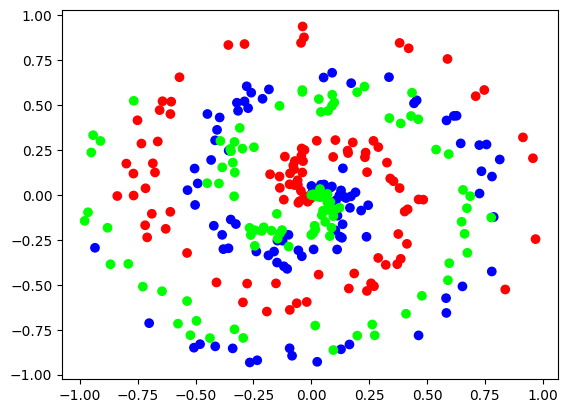

First 5 outputs (probabilities):
 [[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]

Loss: 1.0986104
Accuracy: 0.34

Dense1 weights gradients:
 [[ 1.5766357e-04  7.8368583e-05  4.7324400e-05]
 [ 1.8161038e-04  1.1045573e-05 -3.3096312e-05]]

Dense1 biases gradients:
 [[-3.60553473e-04  9.66117223e-05 -1.03671395e-04]]

Dense2 weights gradients:
 [[ 5.44109462e-05  1.07411419e-04 -1.61822361e-04]
 [-4.07913431e-05 -7.16780924e-05  1.12469446e-04]
 [-5.30112993e-05  8.58172934e-05 -3.28059905e-05]]

Dense2 biases gradients:
 [[-1.0729185e-05 -9.4610732e-06  2.0027859e-05]]


In [56]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

# Create layers
dense1 = Layer_Dense(2, 3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Forward pass
dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
loss = loss_activation.forward(dense2.output, y)

# Print results
print("First 5 outputs (probabilities):\n", loss_activation.output[:5])
print("\nLoss:", loss)

# Calculate accuracy
predictions = np.argmax(loss_activation.output, axis=1)
if len(y.shape) == 2:
    y_discrete = np.argmax(y, axis=1)
else:
    y_discrete = y

accuracy = np.mean(predictions == y_discrete)
print("Accuracy:", accuracy)

# Backward pass
loss_activation.backward(loss_activation.output, y_discrete)
dense2.backward(loss_activation.dinputs)
activation1.backward(dense2.dinputs)
dense1.backward(activation1.dinputs)

# Print gradients
print("\nDense1 weights gradients:\n", dense1.dweights)
print("\nDense1 biases gradients:\n", dense1.dbiases)
print("\nDense2 weights gradients:\n", dense2.dweights)
print("\nDense2 biases gradients:\n", dense2.dbiases)